In [24]:
import os
from dotenv import load_dotenv
load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("bro it is working")


from langchain.chat_models import init_chat_model

llm_model = init_chat_model(model="gpt-5-nano")

bro it is working


In [25]:
from pydantic import BaseModel, Field
from typing import Literal

class llm_schema(BaseModel):
    category: Literal["insta", "twitter", "linkedIn"] = Field(description="Category of the post")
    topic: str = Field(description="Topic of the post")

In [26]:
llm_with_StrcuturedOutput = llm_model.with_structured_output(llm_schema)
# result = llm_with_StrcuturedOutput.invoke("I want to generate the post for LinkedIn for topic AI")
# print(result)
# print(result.category)
# print(result.topic)

In [27]:
from typing import TypedDict, List
class graph_schema(TypedDict):
    input: str
    category: str
    topic: str
    post: str

In [28]:
def decider_node(schema: graph_schema):

    user_input = schema["input"]
    response = llm_with_StrcuturedOutput.invoke(user_input)
    return {
    "category": response.category,
    "topic": response.topic,
    }

In [29]:
def create_post_insta(schema:graph_schema):

    topic = schema["topic"]
    Llm_Response = llm_model.invoke(f" Write a small Instagram post about {topic}").content
    return {"post": Llm_Response}

def create_post_twitter(schema:graph_schema):

    topic = schema["topic"]
    Llm_Response = llm_model.invoke(f"Write a small twitter post about {topic}").content
    return {"post": Llm_Response}


def create_post_linkedIn(schema:graph_schema):

    topic = schema["topic"]
    Llm_Response = llm_model.invoke(f"Write a small linkedIn post about {topic}").content
    return {"post": Llm_Response}



In [30]:
def decider_condtion(schema: graph_schema):

    category = schema["category"]

    if category == "insta":
        return "create_post_insta"
    elif category == "twitter":
        return "create_post_twitter"
    elif category == "linkedIn":
        return "create_post_linkedIn"

In [31]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("decider_node", decider_node)
graph.add_node("create_post_insta", create_post_insta)
graph.add_node("create_post_twitter", create_post_twitter)
graph.add_node("create_post_linkedIn", create_post_linkedIn)

graph.add_edge(START, "decider_node")

graph.add_conditional_edges(
    "decider_node", 
    decider_condtion, 
    {
    "create_post_insta" :"create_post_insta",
    "create_post_twitter": "create_post_twitter",
    "create_post_linkedIn" : "create_post_linkedIn"
},
)

graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_twitter", END)
graph.add_edge("create_post_linkedIn", END)


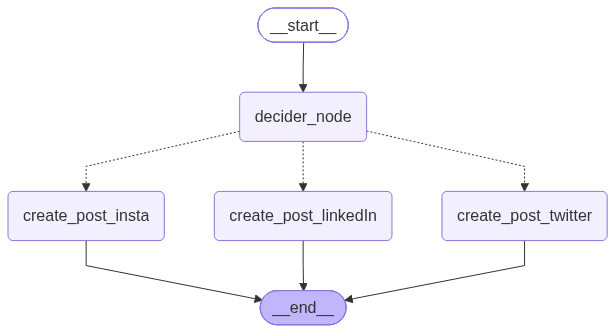

In [32]:
from IPython.display import Image, display

graph = graph.compile()

Image(graph.get_graph().draw_mermaid_png())

In [33]:
graph.invoke({
    "input": "Generate a LinkedIn post about Agentic ai",
    "topic" : "",
    "category" : "",
    "post" : ""
    })

{'input': 'Generate a LinkedIn post about Agentic ai',
 'category': 'linkedIn',
 'topic': 'Agentic AI',
 'post': 'Agentic AI is changing how we work: AI systems that can set goals, plan, and act to reach outcomes—within defined guardrails. When designed responsibly, agentic AI can run experiments, automate routine decision-making, and help teams scale strategic work. The upside: faster iterations, better use of data, and more time for humans to tackle complex problems. The caveats: alignment, safety, transparency, and governance. Start small: pick a narrowly scoped domain, define objectives clearly, keep humans in the loop for critical decisions, and implement observable monitoring. I’m curious where you see agentic AI fitting in your org—what use cases excite you, and what governance practices would you prioritize? #AgenticAI #AI #FutureOfWork #Automation #AIGovernance #EthicalAI'}